In [1]:
!pip freeze

absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==2.4.0
aiofiles==25.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.14.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.14.0
anywidget==0.9.21
apsw==3.53.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.1
astropy-iers-data==0.2026.6.22.1.23.34
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.42.0
bigquery-magics==0.14.0
bleach==6.4.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.5.1
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.6.17
cffi==2.0.0
chard

In [ ]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
    RandomFlip, RandomRotation, RandomZoom)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import CategoricalCrossentropy, CategoricalFocalCrossentropy
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,ModelCheckpoint,TensorBoard)
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.efficientnet import preprocess_input
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import time
import os
import mlflow
from mlflow.tracking import MlflowClient
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Base Path
PATH = '/content/drive/MyDrive/final-project/dataset/data/raw/skin_cropped/skin_types'

In [ ]:
# Load Data Train
train_normal = os.path.join(PATH, 'train', 'normal')
train_oily = os.path.join(PATH, 'train', 'oily')
train_dry = os.path.join(PATH, 'train', 'dry')

In [ ]:
# Review Train Directory
train_group = [train_normal, train_oily, train_dry]
for t in train_group:
    print(f'First 10 Images [{t}]')
    print(os.listdir(t)[:10])
    print('')

First 10 Images [/content/drive/MyDrive/final-project/dataset/data/raw/skin_cropped/skin_types/train/normal]
['image_129.jpg', 'image_13.jpg', 'image_129.webp', 'image_119.jpg', 'image_115.webp', 'image_116.jpg', 'image_117.webp', 'image_127.webp', 'image_126.webp', 'dry_31dc5805e43b23d34f97_jpg.rf.a8851fd407f8e1c84620c7a3cb92388c.jpg']

First 10 Images [/content/drive/MyDrive/final-project/dataset/data/raw/skin_cropped/skin_types/train/oily]
['28_jpg.rf.7006834c6a8765a320f8e298e0773ec9.jpg', 'c15_resized_flipped_horizontal.jpg', '0011ae3a-1600_jpg.rf.6069155cd6e5de48e1a8c11203ba19d8_processed.jpg', '3_jpg.rf.9de71e459b05c8348b43e86f7d5a16d0.jpg', 'c16_resized_flipped_horizontal.jpg', 'acne-prone-skin_155_jpeg.rf.07e9bae361577693aebd6e032d462e88_processed.jpg', '6btilV86QSUkv7xuTd6f35DafDrlae4L1658497365_jpg.rf.63aaaa010ab13fb883503ed85831e087_processed.jpg', 'c13_resized_flipped_horizontal.jpg', '29_jpg.rf.acd694d1eb7ae47589755fee1d31450b.jpg', 'acne-prone-skin_10_jpeg.rf.14f0c8870fb6

## Load Images

In [ ]:
# Load Data Test
test_normal = os.path.join(PATH, 'test', 'normal')
test_oily = os.path.join(PATH, 'test', 'oily')
test_dry = os.path.join(PATH, 'test', 'dry')

In [ ]:
# Review Test Directory
test_group = [test_normal, test_oily, test_dry]
for t in test_group:
    print(f'First 10 Images [{t}]')
    print(os.listdir(t)[:10])
    print('')

First 10 Images [/content/drive/MyDrive/final-project/dataset/data/raw/skin_cropped/skin_types/test/normal]
[]

First 10 Images [/content/drive/MyDrive/final-project/dataset/data/raw/skin_cropped/skin_types/test/oily]
['bd301720-b80c-4620-9824-f91bbd213655-316298803_866631867677867_1840899608698097263_n_jpg.rf.4e1efbcc383b02e299309c878034aab0_processed.jpg', 'acne-prone-skin_119_jpeg.rf.324b93dc3526b1ea6e966491deeb82fd_processed.jpg', 'c2_resized_flipped_horizontal.jpg', 'images11_jpeg.rf.43eb4f0d645d8394f7529f852b98c542_processed.jpg', 'images54_jpeg.rf.b004abcc1477338e83dc7695d2c05403_processed.jpg', 'images26_jpeg.rf.985e5743695afd34477ec777d5e835e3_processed.jpg', 'images9_jpeg.rf.0cfa1ea018e1fcf031a16156bf2cfdee_processed.jpg', 'images50_jpeg.rf.d61f49eac10c21e38d3e87278abcffa4_processed.jpg', 'istockphoto-1445376040-612x612_resized_flipped_horizontal.jpg', 'istockphoto-1528534238-612x612_resized_flipped_horizontal.jpg']

First 10 Images [/content/drive/MyDrive/final-project/datas

In [ ]:
# Load Data Validation
valid_normal = os.path.join(PATH, 'valid', 'normal')
valid_oily = os.path.join(PATH, 'valid', 'oily')
valid_dry = os.path.join(PATH, 'valid', 'dry')

In [ ]:
# Review Validation Directory
valid_group = [valid_normal, valid_oily, valid_dry]
for t in valid_group:
    print(f'First 10 Images [{t}]')
    print(os.listdir(t)[:10])
    print('')

First 10 Images [/content/drive/MyDrive/final-project/dataset/data/raw/skin_cropped/skin_types/valid/normal]
['image_97.jpg', 'image_98.webp', 'normal_skin-16-_jpg.rf.2a983c6658276de9773fd121f75f6ba6.jpg', '63_jpg.rf.30125255340fb2196398f54eae7337ee_processed.jpg', '70_jpg.rf.7151ced0d5bd547079ab74465d443b9b_processed.jpg', 'cropped_right_cheek_1696929891_jpg.rf.83cfb7e4bf852aa26db9b343f5a9abf4.jpg', '0c822b4b1962da350090e9fe209a4ea2.jpg', 'image_102.webp', 'image_123.jpg', 'image_120.jpg']

First 10 Images [/content/drive/MyDrive/final-project/dataset/data/raw/skin_cropped/skin_types/valid/oily]
['c124_resized_flipped_horizontal.jpg', 'Almond-Oil-For-Face-Benefits-And-How-To-Use-Banner74_jpeg.rf.e54d5e053054d96813e027821238b291_processed.jpg', 'c111_resized_flipped_horizontal.jpg', '42395624_resized_blog_jpg.rf.e987a27f128314f8965f68d138e06fb7_processed.jpg', 'c9_resized_flipped_horizontal.jpg', 'Carbon_star_Product_carousel_5_grande_jpg.rf.de87b098ed036ae6d9518a16dff47471_processed.j

## Preprocess for DL

In [ ]:
# Batch Size and Image Size
batch_size = 32
img_size = (380, 380)

# Train Dataset
train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'train'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=True,
    seed=42)

# Validation Dataset
valid_ds = keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'valid'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=False,
    seed=42)

# Test Dataset
test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'test'),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=False,
    seed=42)

# Classes Detail
class_names = train_ds.class_names
n_classes = len(class_names)

print(f'Number of Classes  : {n_classes}')
print(f'Classes Sample     : {class_names}')
print(f'Train Batches      : {len(train_ds)}')
print(f'Validation Batches : {len(valid_ds)}')
print(f'Test Batches       : {len(test_ds)}')

Found 608 files belonging to 3 classes.
Found 68 files belonging to 3 classes.
Found 73 files belonging to 3 classes.
Number of Classes  : 3
Classes Sample     : ['dry', 'normal', 'oily']
Train Batches      : 19
Validation Batches : 3
Test Batches       : 3


In [ ]:
# CHeck Distribution
def check_distribution(ds, split_name, class_names):
    counts = np.zeros(len(class_names), dtype=int)
    for _, labels in ds.unbatch():
        idx = np.argmax(labels.numpy())
        counts[idx] += 1
    print(f'\n[{split_name}]')
    for name, count in zip(class_names, counts):
        print(f'  {name}: {count}')
    print(f'  TOTAL: {counts.sum()}')

check_distribution(train_ds, 'train', class_names)
check_distribution(valid_ds, 'valid', class_names)
check_distribution(test_ds,  'test',  class_names)


[train]
  dry: 135
  normal: 339
  oily: 134
  TOTAL: 608

[valid]
  dry: 13
  normal: 38
  oily: 17
  TOTAL: 68

[test]
  dry: 14
  normal: 42
  oily: 17
  TOTAL: 73


In [ ]:
# Preprocessing
def preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels

# Augment
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomSharpness(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)], name='data_augmentation')

# Apply Core Pipeline
train_ds = train_ds.map(preprocess)
valid_ds = valid_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(tf.data.AUTOTUNE)

## Modeling

In [ ]:
# EfficientNetB3
def transfer_model(n_outputs, img_size=img_size):
    base_model = EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_tensor=None,
        input_shape=(*img_size, 3))
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(*img_size, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(n_outputs, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs, name='EfficientNetB3_FocalLoss_Isolated')
    return model

In [ ]:
# Compile Model
model = transfer_model(n_outputs=3)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2),
    metrics=['accuracy'])
model.summary()

Model: "EfficientNetB3_FocalLoss_Isolated"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 12, 12, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,778 (42.64 MB)

 Trainable params: 394,243 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
# Log Callbacks
log_dir = os.path.join('logs', datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=2),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=3,
        min_lr=1e-7,
        verbose=2),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/final-project/attempt1A/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=2),
    TensorBoard(log_dir=log_dir)]

In [ ]:
# MLFlow Tracking Google Drive
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('file:///content/drive/MyDrive/final-project/mlruns')
mlflow.set_experiment('skinanalysis')

<Experiment: artifact_location='file:///content/drive/MyDrive/final-project/mlruns/902105372568182309', creation_time=1782799447526, effective_trace_archival_retention=None, experiment_id='902105372568182309', last_update_time=1782799447526, lifecycle_stage='active', name='skinanalysis', tags={}, trace_location=None, workspace='default'>

In [ ]:
# Start Client and Run ID
client = MlflowClient()
run_id = '09ccf99c190d47b58a0e294b344bce5b'

In [ ]:
# Get Metric from Run ID
run = client.get_run(run_id)
metrics_history = {}
metric_names = run.data.metrics.keys()
for metric in metric_names:
  history_run = client.get_metric_history(run_id, metric)
  metrics_history[metric] = [metric.value for metric in history_run]

In [ ]:
# Load Params and Metrics
all_params = run.data.params
latest_metrics = run.data.metrics

print("=== PARAMETERS ===")
for key, value in all_params.items():
    print(f"{key}: {value}")

print("\n=== LATEST METRICS ===")
for key, value in latest_metrics.items():
    print(f"{key}: {value}")

=== PARAMETERS ===
backbone: EfficientNetV2S
dense_units: 128
gamma: 1.5
dropout: 0.4
learning_rate: 0.0001

=== LATEST METRICS ===
accuracy: 0.6800000071525574
loss: 0.4554295241832733
val_accuracy: 0.6600000262260437
val_loss: 0.4965037405490875


In [ ]:
# MLFlow Logging
with mlflow.start_run(run_name='logged_attempt5'):
    mlflow.log_params({
        'backbone': 'MobileNetV3Large',
        'dense_units': 256,
        'loss': 'CategoricalFocalCrossentropy(Gamma=3)',
        'dropout': 0.5,
        'learning_rate': 1e-4,
        'activation': 'relu'
    })

    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=50,
        callbacks=callbacks)

    # Log Metric
    for epoch, (acc, loss, val_acc, val_loss) in enumerate(zip(
        history.history['accuracy'],
        history.history['loss'],
        history.history['val_accuracy'],
        history.history['val_loss'])):

        mlflow.log_metrics({
            'accuracy': acc,
            'loss': loss,
            'val_accuracy': val_acc,
            'val_loss': val_loss
        }, step=epoch)

    mlflow.log_artifact('/content/drive/MyDrive/final-project/attempt1A/best_model.keras')

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4515 - loss: 0.1364
Epoch 1: val_loss improved from None to 0.05769, saving model to /content/drive/MyDrive/final-project/attempt1A/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/final-project/attempt1A/best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.5493 - loss: 0.1188 - val_accuracy: 0.7941 - val_loss: 0.0577 - learning_rate: 1.0000e-04
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6642 - loss: 0.0723
Epoch 2: val_loss improved from 0.05769 to 0.04778, saving model to /content/drive/MyDrive/final-project/attempt1A/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/final-project/attempt1A/best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.7188 - loss: 0.0672 - val_accuracy: 0.8382 - val_loss: 0.0478 - learning_rate: 1.0000e-04
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7675 - loss: 0.0546
Epoch

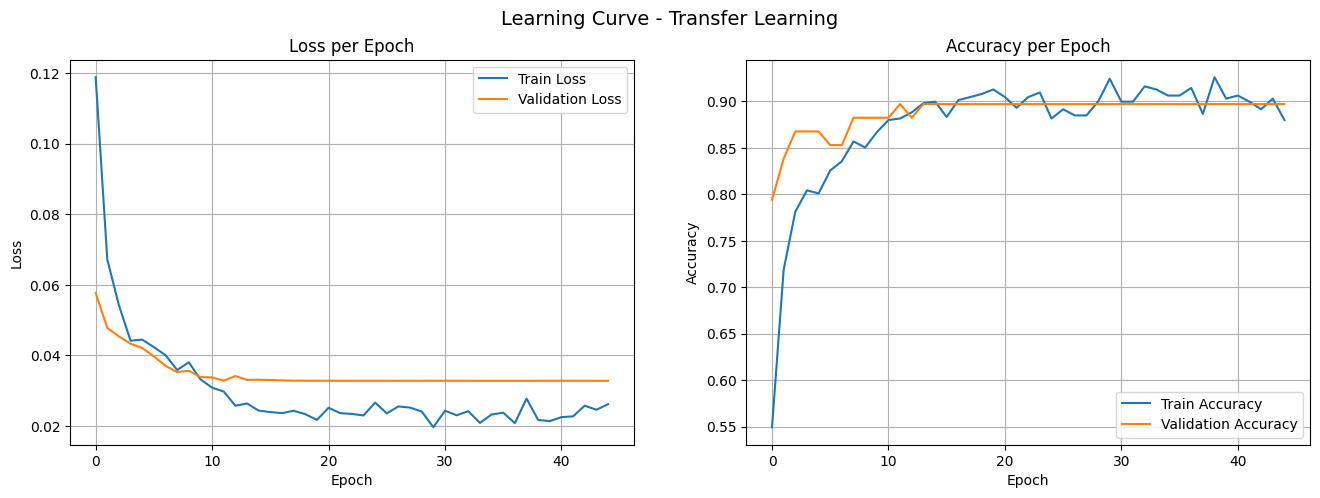

In [ ]:
# Learning Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# Show
plt.suptitle('Learning Curve - Transfer Learning', fontsize=14)
plt.show()

In [ ]:
# Collect Predictions
y_true = []
y_pred = []

for images, labels in valid_ds:
    predictions = model.predict(images, verbose=0)
    y_true.append(np.argmax(labels.numpy(), axis=1))
    y_pred.append(np.argmax(predictions, axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

Classification Report

              precision    recall  f1-score   support

         dry       1.00      0.69      0.82        13
      normal       0.95      0.95      0.95        38
        oily       0.76      0.94      0.84        17

    accuracy                           0.90        68
   macro avg       0.90      0.86      0.87        68
weighted avg       0.91      0.90      0.90        68



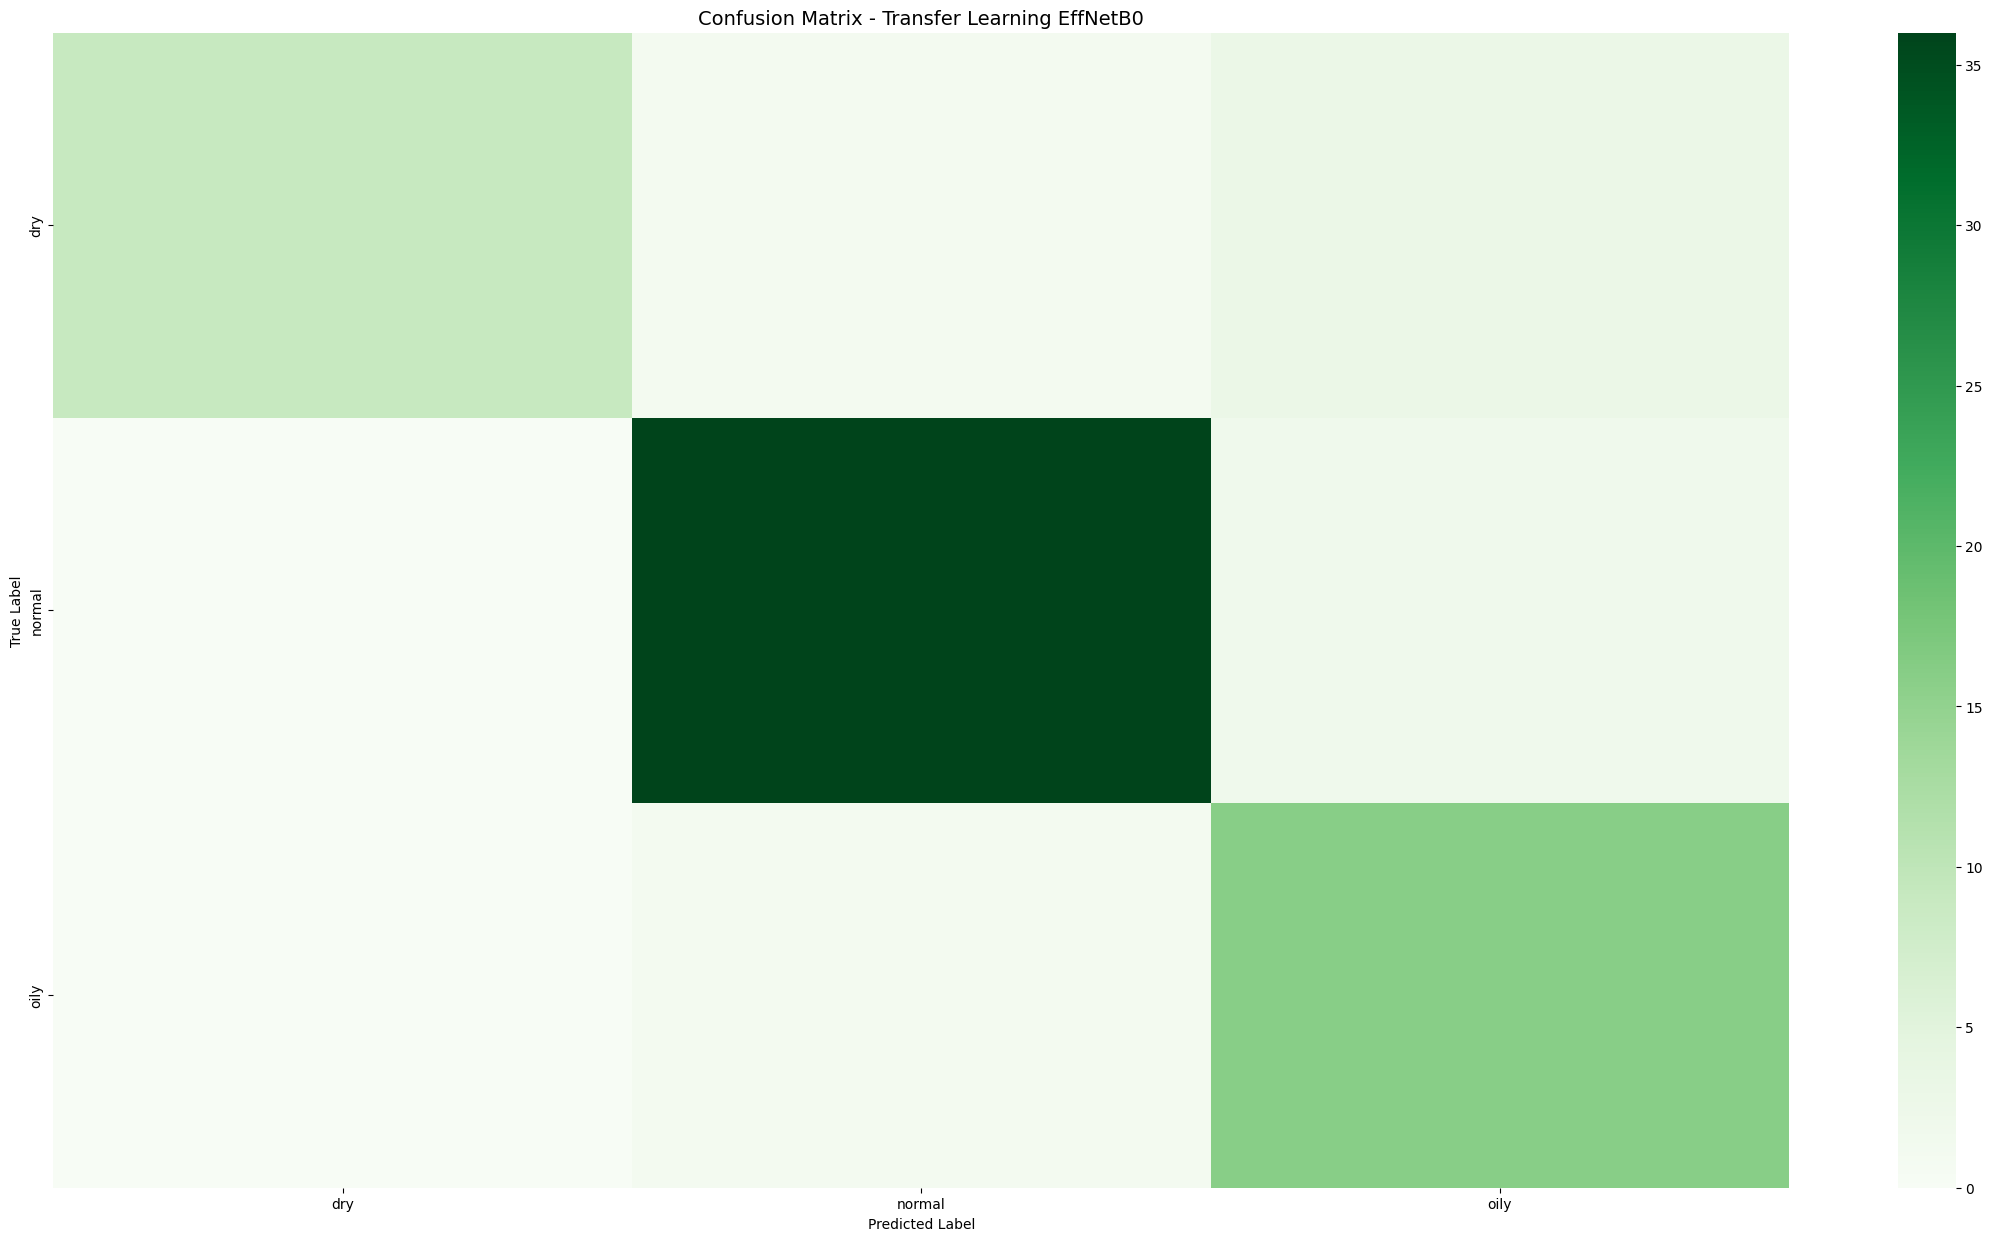

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8971 - loss: 0.0328
Validation Loss : 0.033

Validation Accuracy : 0.897


In [ ]:
# Classification Report
print('Classification Report\n')
print(classification_report(
    y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(28, 15))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Transfer Learning EffNetB0', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Overall Metrics
val_loss, val_accuracy = model.evaluate(valid_ds, verbose=1)
print(f'Validation Loss : {val_loss:.3f}')
print(f'\nValidation Accuracy : {val_accuracy:.3f}')

In [ ]:
# Load Best Model and Unfreeze Layers
model_finetune = tf.keras.models.load_model('/content/drive/MyDrive/final-project/attempt1A/best_model.keras')

backbone = model_finetune.layers[1]
backbone.trainable = True

# Unfreeze Last 40 Layers
for layer in backbone.layers[:-40]:
    layer.trainable = False

for layer in backbone.layers[-40:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = [layer for layer in backbone.layers if layer.trainable]

print(f'Unfrozen Layers: {len(trainable_layers)}')

# Recompile
model_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2),
    metrics=['accuracy'])

# Log Callbacks
log_dir_tuned = os.path.join('logs', 'finetune_' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_tuned = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/final-project/attempt3/best_model.finetuned.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1),
    TensorBoard(log_dir=log_dir_tuned)]

# Fit Fine-tuned Train
history_tuned = model_finetune.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=callbacks_tuned)

Unfrozen Layers: 32
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8818 - loss: 0.0266
Epoch 1: val_loss improved from None to 0.03244, saving model to /content/drive/MyDrive/final-project/attempt3/best_model.finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/final-project/attempt3/best_model.finetuned.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.8947 - loss: 0.0246 - val_accuracy: 0.8971 - val_loss: 0.0324 - learning_rate: 1.0000e-05
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9123 - loss: 0.0234
Epoch 2: val_loss did not improve from 0.03244
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8964 - loss: 0.0246 - val_accuracy: 0.8824 - val_loss: 0.0329 - learning_rate: 1.0000e-05
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9161 - loss: 0.0215
Epoch 3: val_loss improved from 0.03244 to 0.03208, saving model to /content/drive/MyDrive/final-project/attempt3/best_model.finetuned.keras

Epoch 3: f

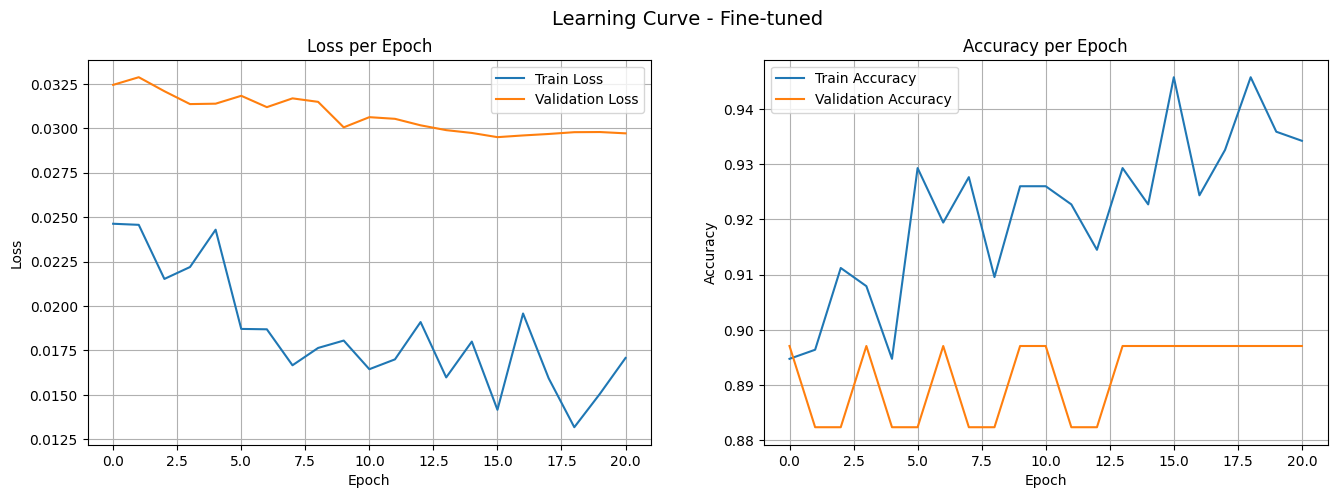

In [ ]:
# Learning Curve Fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_tuned.history['loss'], label='Train Loss')
axes[0].plot(history_tuned.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_tuned.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# Show
plt.suptitle('Learning Curve - Fine-tuned', fontsize=14)
plt.show()

In [ ]:
# Collect Predictions
y_true_tuned = []
y_pred_tuned = []

for images, labels in valid_ds:
    predictions = model_finetune.predict(images, verbose=0)
    y_true_tuned.append(np.argmax(labels.numpy(), axis=1))
    y_pred_tuned.append(np.argmax(predictions, axis=1))

y_true_tuned = np.concatenate(y_true_tuned)
y_pred_tuned = np.concatenate(y_pred_tuned)

Classification Report

              precision    recall  f1-score   support

         dry       0.90      0.69      0.78        13
      normal       0.95      0.95      0.95        38
        oily       0.80      0.94      0.86        17

    accuracy                           0.90        68
   macro avg       0.88      0.86      0.86        68
weighted avg       0.90      0.90      0.90        68



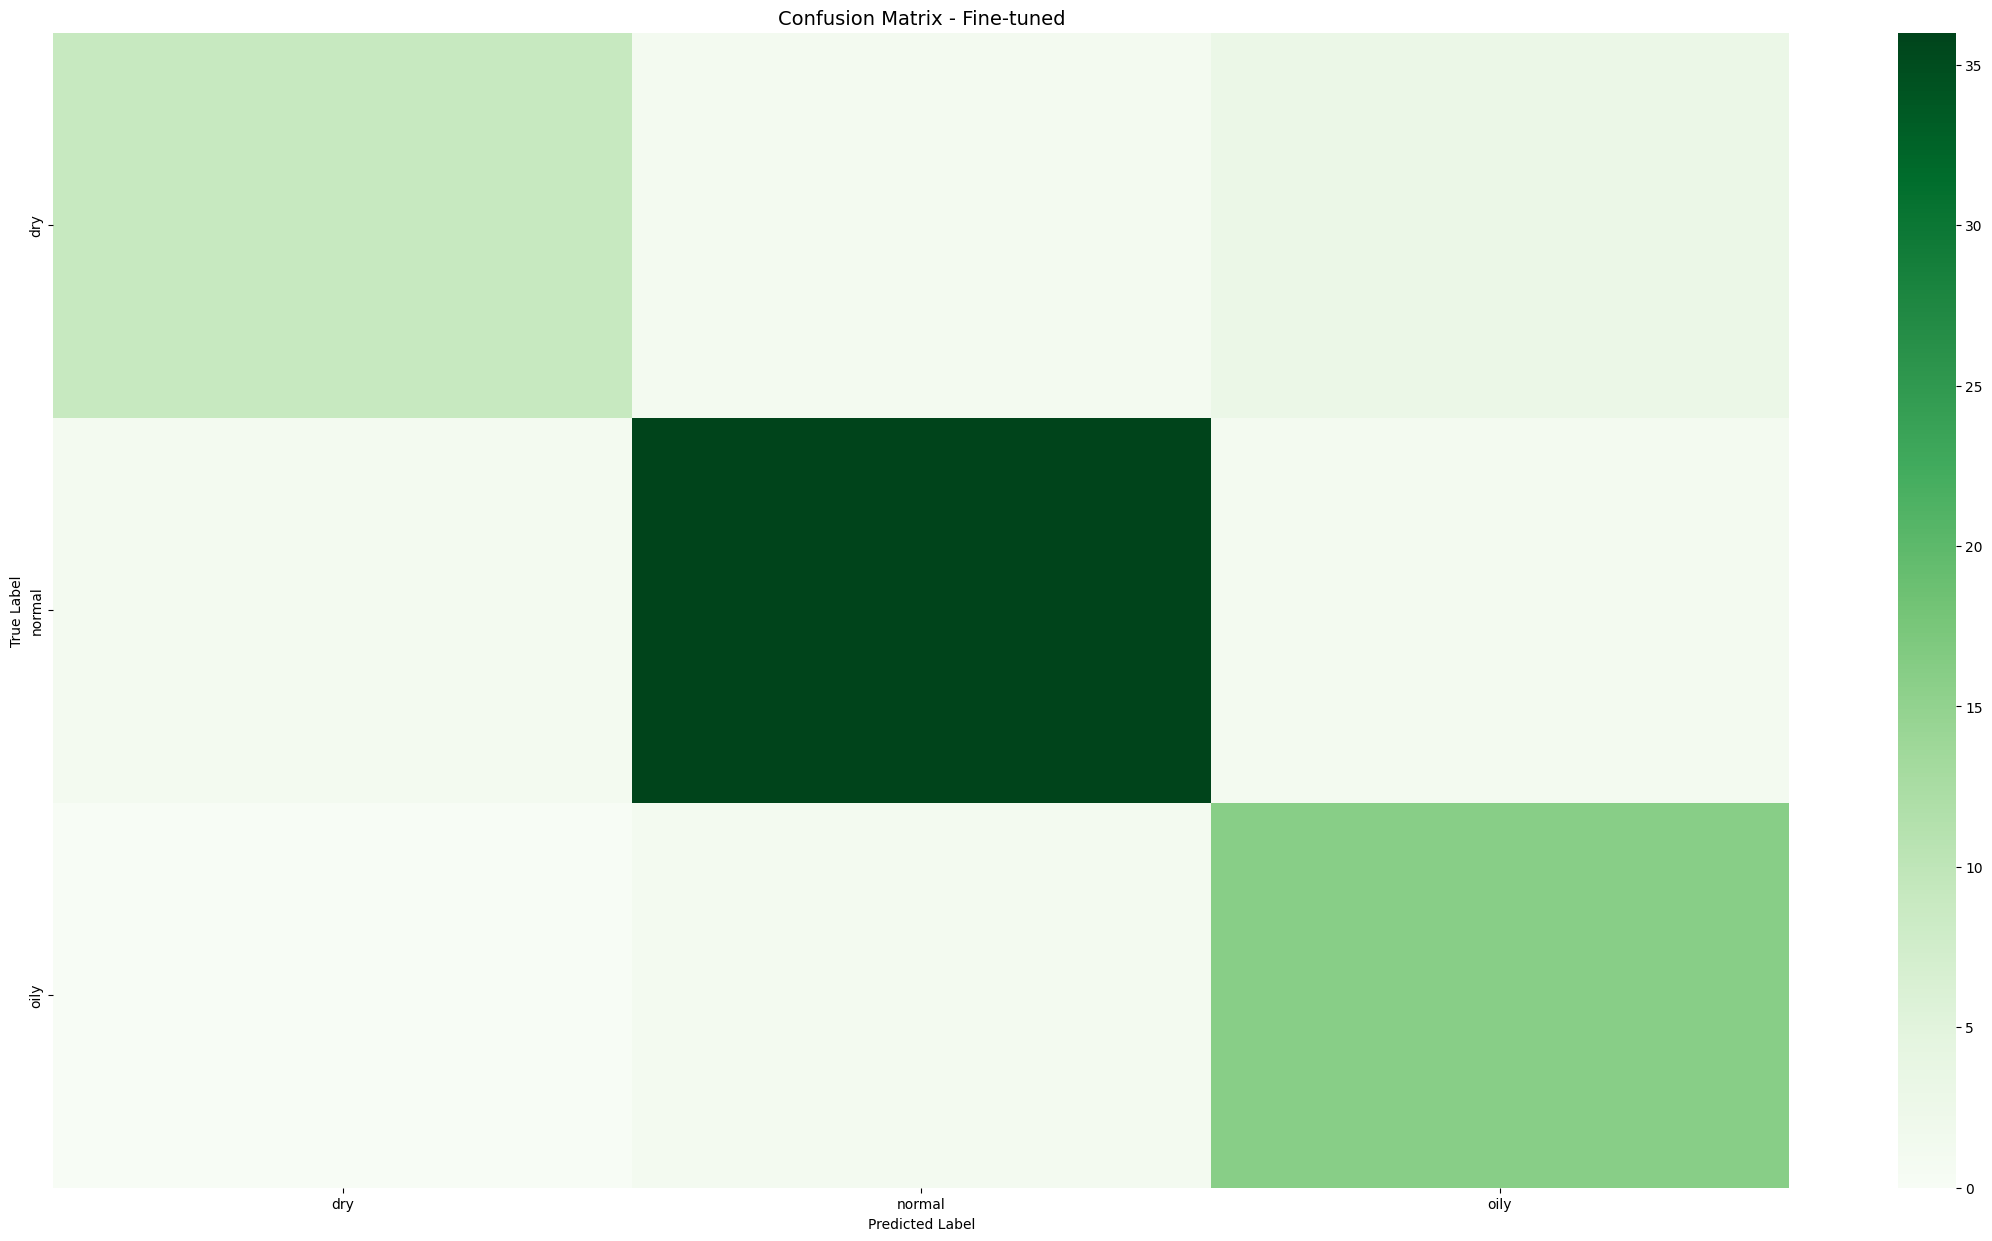

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8971 - loss: 0.0295
Validation Loss : 0.029

Validation Accuracy : 0.897


In [ ]:
# Classification Report
print('Classification Report\n')
print(classification_report(
    y_true_tuned, y_pred_tuned, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true_tuned, y_pred_tuned)

plt.figure(figsize=(28, 15))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fine-tuned', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Overall Metrics
val_loss_tuned, val_accuracy_tuned = model_finetune.evaluate(valid_ds, verbose=1)
print(f'Validation Loss : {val_loss_tuned:.3f}')
print(f'\nValidation Accuracy : {val_accuracy_tuned:.3f}')

In [ ]:
# Evaluate on Test
y_true_test = []
y_pred_test = []

for images, labels in test_ds:
    predictions = model_finetune.predict(images, verbose=0)
    y_true_test.append(np.argmax(labels.numpy(), axis=1))
    y_pred_test.append(np.argmax(predictions, axis=1))

y_true_test = np.concatenate(y_true_test)
y_pred_test = np.concatenate(y_pred_test)

print(classification_report(y_true_test, y_pred_test, target_names=['dry', 'normal', 'oily']))

              precision    recall  f1-score   support

         dry       0.86      0.86      0.86        14
      normal       0.95      0.98      0.96        42
        oily       0.94      0.88      0.91        17

    accuracy                           0.93        73
   macro avg       0.92      0.91      0.91        73
weighted avg       0.93      0.93      0.93        73



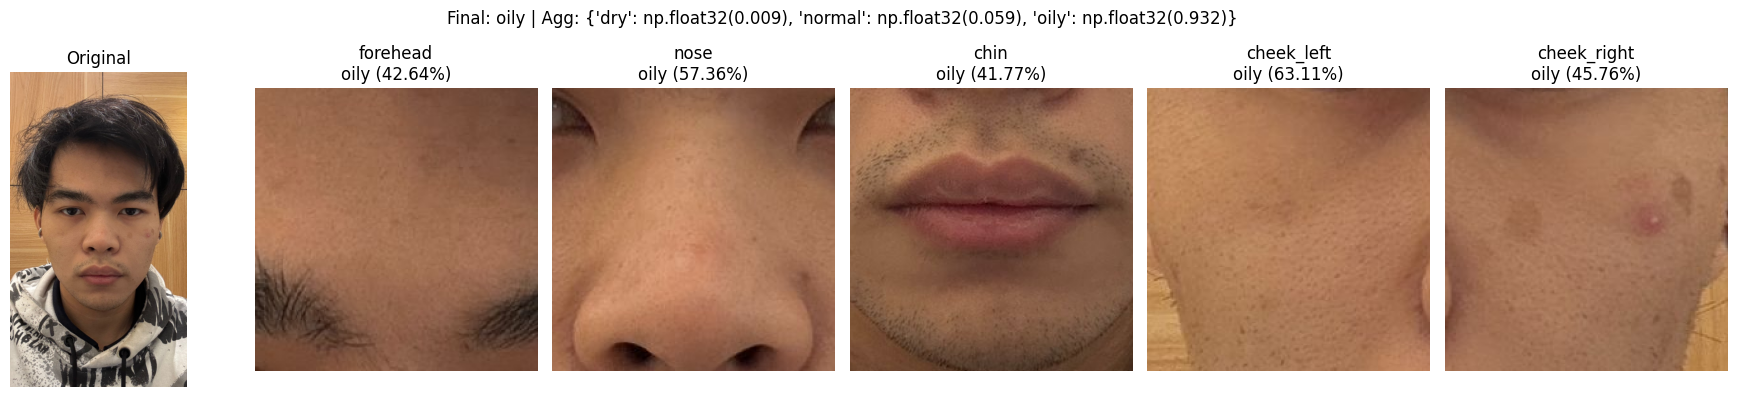


Per-zona:
  forehead      : oily | {'dry': np.float32(0.22), 'normal': np.float32(0.354), 'oily': np.float32(0.426)}
  nose          : oily | {'dry': np.float32(0.125), 'normal': np.float32(0.301), 'oily': np.float32(0.574)}
  chin          : oily | {'dry': np.float32(0.263), 'normal': np.float32(0.319), 'oily': np.float32(0.418)}
  cheek_left    : oily | {'dry': np.float32(0.215), 'normal': np.float32(0.154), 'oily': np.float32(0.631)}
  cheek_right   : oily | {'dry': np.float32(0.188), 'normal': np.float32(0.354), 'oily': np.float32(0.458)}
Aggregated : {'dry': np.float32(0.009), 'normal': np.float32(0.059), 'oily': np.float32(0.932)}
Final type : oily


In [ ]:
# MediaPipe + CNN Test
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Download Model
import urllib.request
urllib.request.urlretrieve(
    'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
    'face_landmarker.task')

# Initialize
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(base_options=base_options, num_faces=1)
face_landmarker = vision.FaceLandmarker.create_from_options(options)

MODEL_PATH = '/content/drive/MyDrive/final-project/attempt3/best_model.finetuned.keras'
IMG_SIZE = (380, 380)
CLASSES = ['dry', 'normal', 'oily']

model_mp = tf.keras.models.load_model(MODEL_PATH)

# Crop Zone by Face BBox
def crop_zones(image_rgb: np.ndarray, bbox) -> dict:
    h, w  = image_rgb.shape[:2]
    x1    = int(bbox.xmin * w)
    y1    = int(bbox.ymin * h)
    bw    = int(bbox.width * w)
    bh    = int(bbox.height * h)
    x2    = x1 + bw
    y2    = y1 + bh

    zones = {
        'forehead':    (x1, y1, x2, y1 + int(bh * 0.30)),
        'nose':        (x1, y1 + int(bh * 0.30), x2, y1 + int(bh * 0.60)),
        'chin':        (x1, y1 + int(bh * 0.60), x2, y2),
        'cheek_left':  (x1, y1 + int(bh * 0.30), x1 + int(bw * 0.35), y1 + int(bh * 0.70)),
        'cheek_right': (x2 - int(bw * 0.35), y1 + int(bh * 0.30), x2, y1 + int(bh * 0.70)),
    }

    crops = {}
    for name, (zx1, zy1, zx2, zy2) in zones.items():
        crop = image_rgb[zy1:zy2, zx1:zx2]
        if crop.size == 0:
            continue
        size   = min(crop.shape[:2])
        ch, cw = crop.shape[:2]
        crops[name] = crop[(ch-size)//2:(ch+size)//2, (cw-size)//2:(cw+size)//2]

    return crops


# Log-Probability Aggregation
def aggregate_log_prob(preds: list) -> np.ndarray:
    log_probs = np.sum([np.log(p + 1e-9) for p in preds], axis=0)
    exp_log   = np.exp(log_probs - np.max(log_probs))
    return exp_log / exp_log.sum()


# Combination via Rule
def derive_skin_type(zone_preds: dict) -> str:
    t_zone = [zone_preds.get('forehead'), zone_preds.get('nose')]
    u_zone = [zone_preds.get('cheek_left'), zone_preds.get('cheek_right'), zone_preds.get('chin')]
    t_zone = [z for z in t_zone if z]
    u_zone = [z for z in u_zone if z]

    t_oily = sum(z == 'oily' for z in t_zone) / len(t_zone) if t_zone else 0
    u_dry = sum(z in ('dry', 'normal') for z in u_zone) / len(u_zone) if u_zone else 0

    if t_oily >= 0.5 and u_dry >= 0.67:
        return 'combination'

    all_zones = t_zone + u_zone
    return max(set(all_zones), key=all_zones.count)

# Main Test
def test_integration(image_path: str):
    image_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    results = face_landmarker.detect(mp_image)

    if not results.face_landmarks:
      print('Wajah tidak terdeteksi.')
      return

    landmarks = results.face_landmarks[0]
    xs = [lm.x for lm in landmarks]
    ys = [lm.y for lm in landmarks]

    class BBox:
        xmin  = min(xs)
        ymin  = min(ys)
        width = max(xs) - min(xs)
        height= max(ys) - min(ys)

    crops = crop_zones(image_rgb, BBox())
    zone_probs = {}
    zone_preds = {}

    for name, crop in crops.items():
        img = tf.image.resize(crop, IMG_SIZE).numpy()
        img = preprocess_input(img)
        probs = model_mp.predict(np.expand_dims(img, 0), verbose=0)[0]
        zone_probs[name] = probs
        zone_preds[name] = CLASSES[np.argmax(probs)]

    agg_probs = aggregate_log_prob(list(zone_probs.values()))
    final_type = derive_skin_type(zone_preds)

    # Visualize
    fig, axes = plt.subplots(1, len(crops) + 1, figsize=(18, 4))
    axes[0].imshow(image_rgb)
    axes[0].set_title('Original')
    axes[0].axis('off')

    for i, (name, crop) in enumerate(crops.items()):
        conf = zone_probs[name][np.argmax(zone_probs[name])]
        axes[i+1].imshow(crop)
        axes[i+1].set_title(f'{name}\n{zone_preds[name]} ({conf:.2%})')
        axes[i+1].axis('off')

    plt.suptitle(f'Final: {final_type} | Agg: {dict(zip(CLASSES, agg_probs.round(3)))}')
    plt.tight_layout()
    plt.show()

    print('\nPer-zona:')
    for name, pred in zone_preds.items():
        print(f'  {name:<14}: {pred} | {dict(zip(CLASSES, zone_probs[name].round(3)))}')
    print(f'Aggregated : {dict(zip(CLASSES, agg_probs.round(3)))}')
    print(f'Final type : {final_type}')

test_integration('/content/drive/MyDrive/final-project/image_test/me.jpeg')